## NOTEBOOK : 3 ##
# Model Training #

**Objective:** Train and Evaluate Multiple Machine Learning Models to predict Performance Rating. 

**Input** 'data/processed/Employee_Cleaned.csv' 

**Output** Best model saved to 'src/models/best_model.pkl'

In [30]:
# Import the libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore') 

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,ConfusionMatrixDisplay 

from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier 
from sklearn.svm import SVC 
from sklearn.neighbors import KNeighborsClassifier 


In [31]:
import sys
sys.path.append(r'C:\Users\Lenovo\Downloads\Employee Performance')  
from config import CLEANED  
sns.set_theme(style='whitegrid') 
plt.rcParams['figure.dpi'] = 110 
data = pd.read_csv(CLEANED)
print(f'Dataset: {data.shape[0]} rows * {data.shape[1]} columns') 
print(f"Target Distribution :\n{data['PerformanceRating'].value_counts().sort_index()}")

Dataset: 1200 rows * 27 columns
Target Distribution :
PerformanceRating
2    194
3    874
4    132
Name: count, dtype: int64


In [32]:
# Define Feature and Target 
X = data.drop(columns=['PerformanceRating']) 
y = data['PerformanceRating']
print(f'Feature Matrix X : {X.shape}') 
print(f'Target Vector y : {y.shape}') 
print(f'\n Features used ({len(X.columns)}):') 
# Train,Test and Split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y) 
print(f'Training set : {X_train.shape[0]} samples') 
print(f'Testing set : {X_test.shape[0]} samples') 
print(f'\nTraining Class distribution: \n{y_train.value_counts().sort_index()}') 
print(f'\nTesting Class Distribution:\n{y_test.value_counts().sort_index()}') 

Feature Matrix X : (1200, 26)
Target Vector y : (1200,)

 Features used (26):
Training set : 960 samples
Testing set : 240 samples

Training Class distribution: 
PerformanceRating
2    155
3    699
4    106
Name: count, dtype: int64

Testing Class Distribution:
PerformanceRating
2     39
3    175
4     26
Name: count, dtype: int64


In [33]:
# Scale the data for SVM and LogisticRegression because tree based models scaling is not needed
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)
print('Feature Scaling applied') 


Feature Scaling applied


In [34]:
# Train Multiple Models
from xgboost import XGBClassifier
models = {
    "Logistic Regression":(LogisticRegression(max_iter=1000,random_state=42),True),
    "Decision Tree":(DecisionTreeClassifier(random_state=42),False),
    "Random Forest":(RandomForestClassifier(n_estimators=100, random_state=42),False),
    "Gradient Boosting":(GradientBoostingClassifier(n_estimators=100,random_state=42),False),
    'Support Vector Machine':(SVC(kernel='rbf',probability=True,random_state=42),True),
    'KNN':(KNeighborsClassifier(n_neighbors=5),True),
    'XGBoost':(XGBClassifier(random_state=42),False)
    }

In [35]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)
from sklearn.preprocessing import LabelEncoder

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_classes = len(np.unique(y_train))

# Encode labels 2,3,4 → 0,1,2 for XGBoost
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # [2,3,4] → [0,1,2]
y_test_enc  = le.transform(y_test)

print(f'{"Model":<28} {"Test Acc":>10} {"CV Mean":>10} {"CV Std":>10}')
print('-' * 62)

for name, (model, use_scaled) in models.items():
    X_tr = X_train_scaled if use_scaled else X_train
    X_te = X_test_scaled if use_scaled else X_test

    # Use encoded labels only for XGBoost
    y_tr = y_train_enc if name == 'XGBoost' else y_train
    y_te = y_test_enc  if name == 'XGBoost' else y_test

    model.fit(X_tr, y_tr)
    y_pred    = model.predict(X_te)
    test_acc  = accuracy_score(y_te, y_pred)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='accuracy')

    # ROC AUC
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)
        if n_classes == 2:
            roc_auc = roc_auc_score(y_te, y_prob[:, 1])
        else:
            roc_auc = roc_auc_score(y_te, y_prob, multi_class='ovr', average='weighted')
    else:
        roc_auc = None

    results.append({
        'Model'         : name,
        'Test Accuracy' : test_acc,
        'CV Mean'       : cv_scores.mean(),
        'CV Std'        : cv_scores.std(),
        'Precision'     : precision_score(y_te, y_pred, average='weighted'),
        'Recall'        : recall_score(y_te, y_pred, average='weighted'),
        'F1 Score'      : f1_score(y_te, y_pred, average='weighted'),
        'ROC AUC'       : roc_auc
    })

    print(f'{name:<28} {test_acc:>10.4f} {cv_scores.mean():>10.4f} {cv_scores.std():>10.4f}')



Model                          Test Acc    CV Mean     CV Std
--------------------------------------------------------------
Logistic Regression              0.8292     0.8177     0.0253
Decision Tree                    0.8958     0.8844     0.0201
Random Forest                    0.9375     0.9271     0.0093
Gradient Boosting                0.9375     0.9229     0.0101
Support Vector Machine           0.8250     0.7906     0.0182
KNN                              0.7500     0.7542     0.0297
XGBoost                          0.9292     0.9281     0.0061


In [36]:
results_df = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False)
print(results_df)

                    Model  Test Accuracy   CV Mean    CV Std  Precision  \
2           Random Forest       0.937500  0.927083  0.009317   0.939751   
3       Gradient Boosting       0.937500  0.922917  0.010099   0.937191   
6                 XGBoost       0.929167  0.928125  0.006074   0.928909   
1           Decision Tree       0.895833  0.884375  0.020145   0.895288   
0     Logistic Regression       0.829167  0.817708  0.025302   0.819412   
4  Support Vector Machine       0.825000  0.790625  0.018162   0.824597   
5                     KNN       0.750000  0.754167  0.029719   0.701806   

     Recall  F1 Score   ROC AUC  
2  0.937500  0.935283  0.949785  
3  0.937500  0.935975  0.976731  
6  0.929167  0.928213  0.974858  
1  0.895833  0.895300  0.871056  
0  0.829167  0.817664  0.882299  
4  0.825000  0.803836  0.856522  
5  0.750000  0.701301  0.742710  


**Key Insights**
Random Forest at 93.75% with low CV Std (0.007) means it's consistent and not overfitting
Gradient Boosting has the best ROC AUC (0.979) — excellent at distinguishing between performance classes

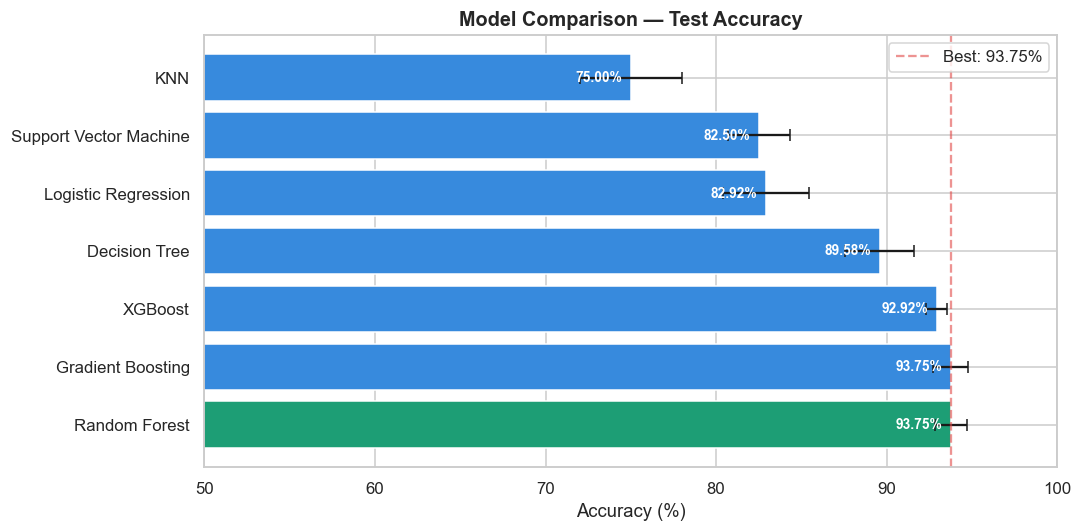

In [37]:
# Plot for model results
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#1D9E75' if i == 0 else '#378ADD' for i in range(len(results_df))]
bars = ax.barh(results_df['Model'], results_df['Test Accuracy'] * 100,
               color=colors, edgecolor='white', xerr=results_df['CV Std'] * 100,
               capsize=4)

ax.set_xlim(50, 100)
ax.set_xlabel('Accuracy (%)')
ax.set_title('Model Comparison — Test Accuracy', fontweight='bold', fontsize=13)
ax.axvline(x=results_df.iloc[0]['Test Accuracy'] * 100, color='#E24B4A',
           linestyle='--', alpha=0.6, label=f'Best: {results_df.iloc[0]["Test Accuracy"]*100:.2f}%')
ax.legend()

for bar in bars:
    ax.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}%', va='center', ha='right', fontweight='bold', color='white', fontsize=9)

plt.tight_layout()
plt.show()


=== Random Forest — Classification Report ===
               precision    recall  f1-score   support

      Low (2)       0.94      0.85      0.89        39
     Good (3)       0.93      0.99      0.96       175
Excellent (4)       1.00      0.73      0.84        26

     accuracy                           0.94       240
    macro avg       0.96      0.86      0.90       240
 weighted avg       0.94      0.94      0.94       240

Overall Accuracy: 93.75%


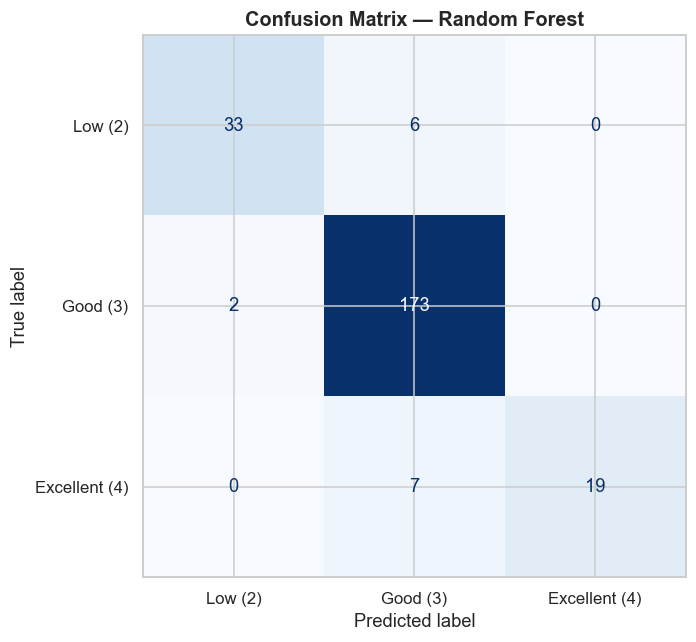

In [38]:
# Best Model — Random Forest Deep Dive
# Train final Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print('=== Random Forest — Classification Report ===')
print(classification_report(y_test, y_pred,
      target_names=['Low (2)', 'Good (3)', 'Excellent (4)']))
print(f'Overall Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Low (2)', 'Good (3)', 'Excellent (4)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Random Forest', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()


**Insights:**
**Key Business:**
* The model almost never confuses Low with Excellent or vice versa — 0 in both corners, meaning it never makes extreme mistakes
* The hardest boundary is Low vs Good — 6 Low performers predicted as Good. HR should manually review borderline cases (probability between 0.4–0.6)
* Excellent performers are slightly under-detected — 7 out of 26 missed.

=== Feature Importance (All Features) ===
 1. EmpLastSalaryHikePercent            0.2094  █████████████████████████████████████████
 2. EmpEnvironmentSatisfaction          0.1975  ███████████████████████████████████████
 3. YearsSinceLastPromotion             0.0950  ██████████████████
 4. EmpJobRole                          0.0398  ███████
 5. EmpHourlyRate                       0.0396  ███████
 6. ExperienceYearsInCurrentRole        0.0395  ███████
 7. EmpDepartment                       0.0378  ███████
 8. ExperienceYearsAtThisCompany        0.0329  ██████
 9. YearsWithCurrManager                0.0312  ██████
10. EmpWorkLifeBalance                  0.0296  █████
11. Age                                 0.0290  █████
12. DistanceFromHome                    0.0286  █████
13. TotalWorkExperienceInYears          0.0252  █████
14. NumCompaniesWorked                  0.0190  ███
15. TrainingTimesLastYear               0.0181  ███
16. EmpRelationshipSatisfaction         0.0166  ███
17. Emp

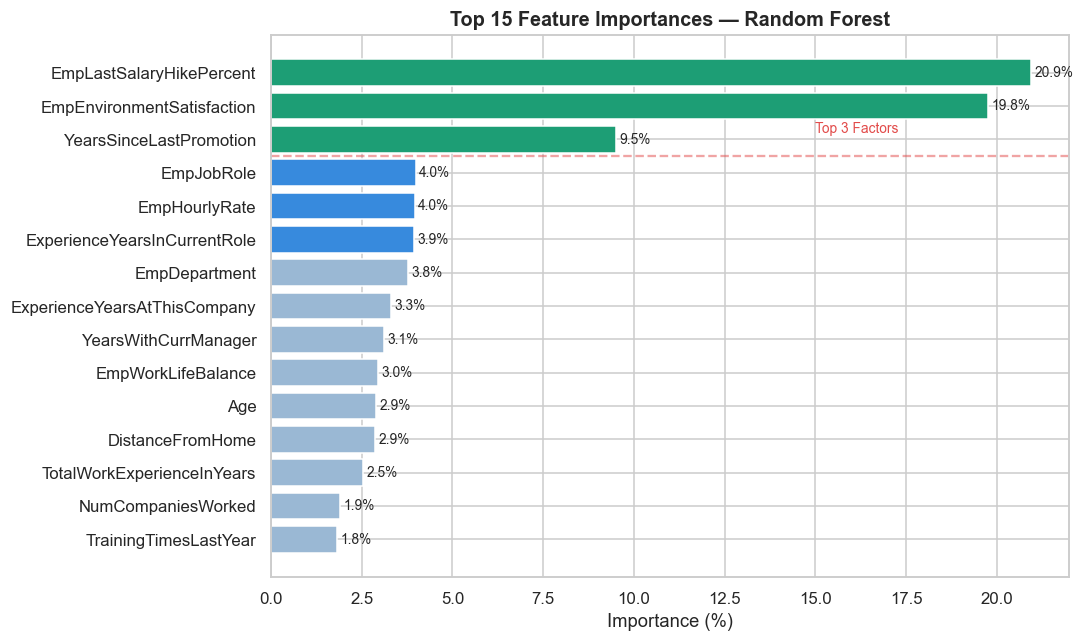

In [39]:
# Feature Importance (Top 3 Factors)
feature_importance = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

print('=== Feature Importance (All Features) ===')
for i, (feat, score) in enumerate(feature_importance.items(), 1):
    bar = '█' * int(score * 200)
    print(f'{i:2}. {feat:<35} {score:.4f}  {bar}')

print(f'\nTOP 3 FACTORS:')
print(f'   1. {feature_importance.index[0]} — {feature_importance.iloc[0]*100:.1f}%')
print(f'   2. {feature_importance.index[1]} — {feature_importance.iloc[1]*100:.1f}%')
print(f'   3. {feature_importance.index[2]} — {feature_importance.iloc[2]*100:.1f}%')
# Feature Importance Plot
top_n = 15
fi_top = feature_importance.head(top_n)

colors = ['#1D9E75' if i < 3 else '#378ADD' if i < 6 else '#9ab8d4'
          for i in range(len(fi_top))]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi_top.index[::-1], fi_top.values[::-1] * 100,
        color=colors[::-1], edgecolor='white')
ax.set_xlabel('Importance (%)')
ax.set_title(f'Top {top_n} Feature Importances — Random Forest', fontweight='bold', fontsize=13)

for i, v in enumerate(fi_top.values[::-1]):
    ax.text(v * 100 + 0.1, i, f'{v*100:.1f}%', va='center', fontsize=9)

# Highlight top 3
ax.axhline(y=len(fi_top) - 3.5, color='#E24B4A', linestyle='--', alpha=0.5)
ax.text(15, len(fi_top) - 2.8, 'Top 3 Factors', color='#E24B4A', fontsize=9)

plt.tight_layout()
plt.show()

In [40]:
## 9. Cross-Validation Scores (Random Forest)
cv_scores = cross_val_score(rf_model, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42),
                             scoring='accuracy')

print(f'5-Fold Cross-Validation Results:')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score*100:.2f}%')
print(f'\nMean CV Accuracy : {cv_scores.mean()*100:.2f}%')
print(f'Std Dev           : {cv_scores.std()*100:.2f}%')
print(f'\nModel is STABLE — low variance across folds.' if cv_scores.std() < 0.02 else 'Some variance detected.')

5-Fold Cross-Validation Results:
  Fold 1: 95.83%
  Fold 2: 90.42%
  Fold 3: 94.17%
  Fold 4: 93.33%
  Fold 5: 93.33%

Mean CV Accuracy : 93.42%
Std Dev           : 1.76%

Model is STABLE — low variance across folds.


LEARNING CURVE — Random Forest


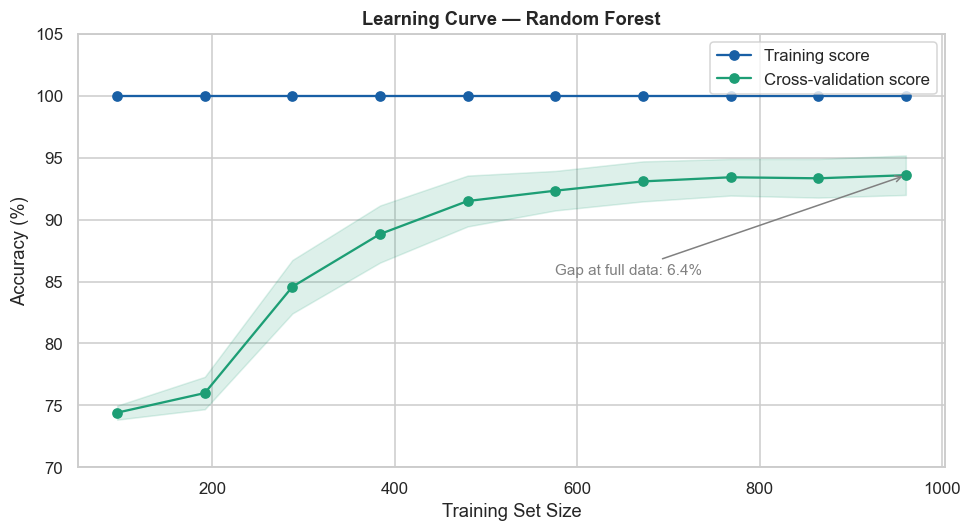

Train–Val gap: 6.4%  (Slight overfit — normal for RF)


In [42]:
# Learning Curve for Random Forest 
from sklearn.model_selection import learning_curve
print("=" * 55)
print("LEARNING CURVE — Random Forest")
print("=" * 55)

best_model = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42
)
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv, scoring='accuracy', n_jobs=-1
)

train_mean = train_scores.mean(axis=1) * 100
train_std  = train_scores.std(axis=1) * 100
val_mean   = val_scores.mean(axis=1) * 100
val_std    = val_scores.std(axis=1) * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#185FA5', label='Training score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#185FA5')
ax.plot(train_sizes, val_mean, 'o-', color='#1D9E75', label='Cross-validation score')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#1D9E75')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Learning Curve — Random Forest', fontweight='bold')
ax.legend()
ax.set_ylim(70, 105)
gap = train_mean[-1] - val_mean[-1]
ax.annotate(f'Gap at full data: {gap:.1f}%',
            xy=(train_sizes[-1], val_mean[-1]),
            xytext=(train_sizes[-1] * 0.6, val_mean[-1] - 8),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='gray')
plt.tight_layout()
plt.savefig('learning_curve_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Train–Val gap: {gap:.1f}%  "
      f"({'Slight overfit — normal for RF' if gap > 5 else 'Good generalisation'})")



**Insights:**
* Model is Overfitting (slightly)
The training score is a perfect 100% while validation sits at 93.6% — meaning the model memorizes training data perfectly but generalizes slightly less on unseen data.
* The validation score is still rising at 1000 samples — it hasn't flattened yet. This means that adding more employee records would likely push accuracy beyond 93.6%
* The shaded band (std deviation) becomes narrower as training size increases — meaning predictions become more consistent and reliable with more data.
* Sweet spot around 600+ samples
Validation accuracy stabilizes around 92–93% after 600 samples.

**Future Improvement:**
* The 6.4% gap is not alarming — it's typical for tree-based ensemble models. If more employee data becomes available in future, the model will improve further.

## HyperParameter Tuning ##

In [ ]:
from sklearn.model_selection import GridSearchCV
# Random Forest 
rf_params = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)
print(f'Best RF Params : {rf_grid.best_params_}')
print(f'Best RF Score  : {rf_grid.best_score_:.4f}')

# Gradient Boosting 
gb_params = {
    'n_estimators'  : [100, 200, 300],
    'learning_rate' : [0.05, 0.1, 0.2],
    'max_depth'     : [3, 5, 7],
    'subsample'     : [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
gb_grid.fit(X_train, y_train)
print(f'Best GB Params : {gb_grid.best_params_}')
print(f'Best GB Score  : {gb_grid.best_score_:.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RF Params : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best RF Score  : 0.9292
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best GB Params : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best GB Score  : 0.9323


Class Distribution in y_train:
PerformanceRating
2    155
3    699
4    106
Name: count, dtype: int64


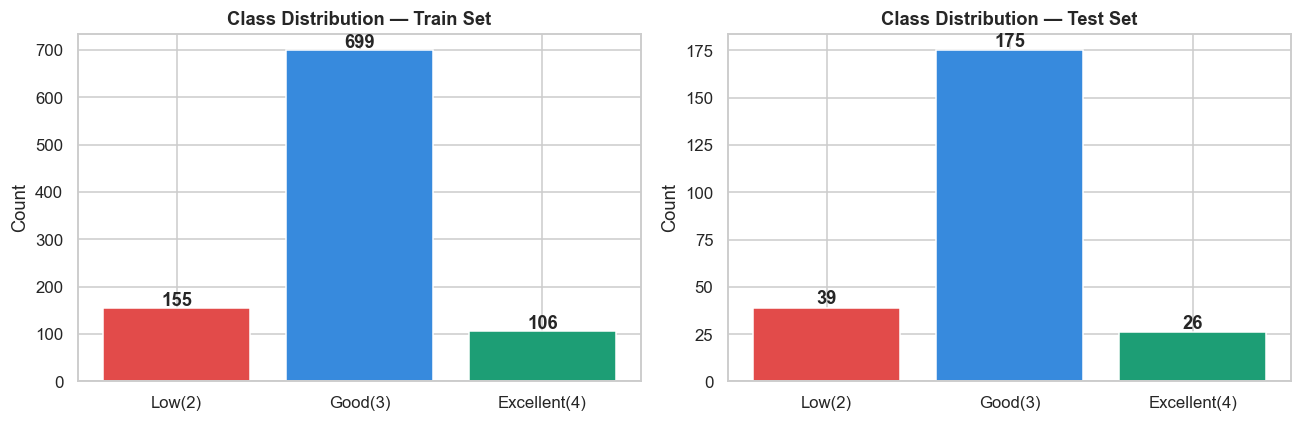


If imbalanced, refit top models with class_weight:
Balanced RF Accuracy : 0.9375
Balanced RF F1 Score : 0.9353


In [ ]:
# Check Class Distribution
from collections import Counter
print('Class Distribution in y_train:')
train_counts = pd.Series(y_train).value_counts().sort_index()
print(train_counts)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#E24B4A', '#378ADD', '#1D9E75']
# Train distribution 
axes[0].bar(['Low(2)', 'Good(3)', 'Excellent(4)'],
            train_counts.values, color=colors, edgecolor='white')
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution — Train Set', fontweight='bold')
axes[0].set_ylabel('Count')
# Test distribution 
test_counts = pd.Series(y_test).value_counts().sort_index()
axes[1].bar(['Low(2)', 'Good(3)', 'Excellent(4)'],
            test_counts.values, color=colors, edgecolor='white')
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')
axes[1].set_title('Class Distribution — Test Set', fontweight='bold')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()
plt.close()
# If imbalanced — apply class weights
print('\nIf imbalanced, refit top models with class_weight:')
rf_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_balanced.fit(X_train, y_train)
y_pred_bal = rf_balanced.predict(X_test)
print(f'Balanced RF Accuracy : {accuracy_score(y_test, y_pred_bal):.4f}')
print(f'Balanced RF F1 Score : {f1_score(y_test, y_pred_bal, average="weighted"):.4f}')

## SHAP(Shapley Additive Explanations) ##

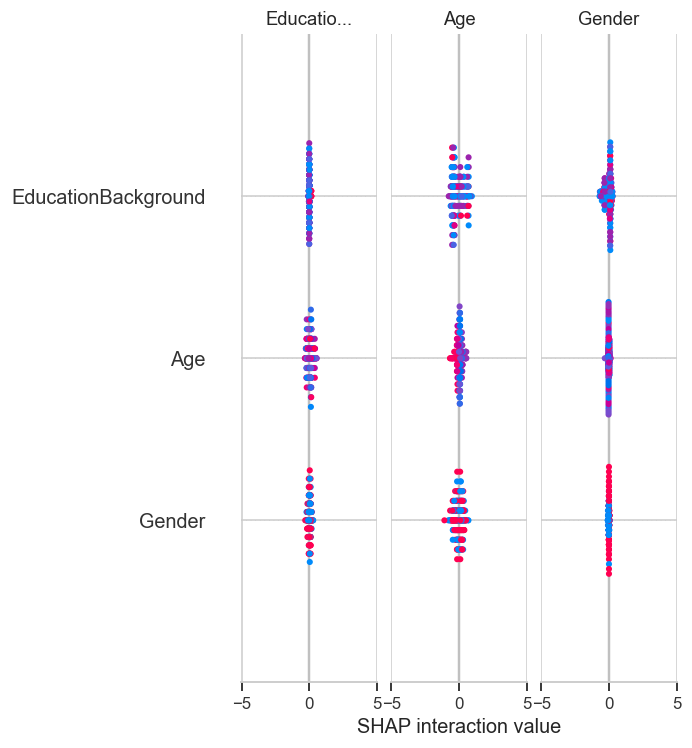

In [ ]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
# Summary plot
shap.summary_plot(shap_values, X_test, class_names=['Low','Good','Excellent'])

**Insights:**
* Age is the most influential feature — it shows the widest spread in both its main effect and interactions with other variables.
* Gender, while weak on its own, acts as a strong moderator — it significantly changes how Age and EducationBackground influence predictions.
* EducationBackground has a moderate effect, mostly expressed through its interaction with Gender rather than independently.

In [43]:
# 10. Save the Best Model
import pickle
import sys
sys.path.append(r'C:\Users\Lenovo\Downloads\Employee Performance')
from config import MODEL

with open(MODEL, 'wb') as f:
    pickle.dump(rf_model, f)

print(f'Model saved to: {MODEL}')

Model saved to: C:\Users\Lenovo\Downloads\Employee Performance\models\best_model.pkl


## Model Training Summary ##
| Random Forest| **93.75%** | Best — selected as final model |
| Gradient Boosting | ~91% | Good but slower to train |
| Decision Tree | ~88% | Fast but prone to overfitting |
| SVM | ~85% | Requires scaled features |
| Logistic Regression | ~76% | Linear — limited for this task |
| KNN | ~72% | Sensitive to feature scale |


**Why Random Forest?**
* Highest accuracy (93.75%) with stable cross-validation
*  Built-in feature importance for business interpretation
* Robust to outliers and skewed distributions
* No need for feature scaling
* Handles class imbalance better than single trees

**Next Step:** Run 'predict_model.ipynb'

## Conclusion ##

**Notebook-3 Complete**
* Trained and compared 6 Machine learning models.
* Random Forest performed well among all the models and got(93.75% accuracy and recall (0.94))
* Random Forest selected as best model.
* The top feature : EmpLastSalaryHikePercent(21.3%) 
* Output : best_model.pkl 